<a href="https://colab.research.google.com/github/amina-mardiyyah/Data_Science_For_Life_Scientist_Course/blob/main/session1B__finetune_a_pretrained_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 1B Tutorial Notebook: Fine-tuning a Pretrained Transformer on Text Classification

**Course:** Data Science for Life Scientists  
**Practical focus:** Sentence classification with the PubMed RCT 20k dataset

By the end of this notebook, you will:
- inspect a biomedical text classification dataset
- fine-tune a pretrained transformer on sentence classification
- save predictions and metrics that will feed into Session 2, where we will focus on evaluation and visualisation

This notebook uses the same task and label space as the DNN notebook so the two models can be compared fairly.

In [ ]:
!pip install uv
!uv pip install transformers==4.48.2 datasets==3.0.2 evaluate==0.4.5

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 359ms


## Dataset description

We will use the cleaned **PubMed RCT 20k** sentence-classification subset from Hugging Face.

Just as before in Part A, the task is to classify each sentence from a biomedical abstract into one of five labels:
**background, objective, methods, results,** or **conclusions**.

The same dataset and label order are used as in Session 1A so that the performance of the DNN and transformer can be compared on the same problem.

In [ ]:
# Dependency imports

#Standard
import os
import json
import random
import pprint
from pathlib import Path

#data manipulation and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# scikit-learn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# PyTorch, transformers and HF datasets
from datasets import load_dataset
import torch
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

# Ignore unnecessary library warnings
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)


In [ ]:
# Reproducibility
SEED = 42  # Other values to try later: 3407, 2026, 123

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Pretrained model checkpoint
MODEL_NAME = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'

# Training hyperparameters
MAX_LENGTH = 128
LR = 2e-5
NUM_EPOCHS = 3

# Output folders for Session 2
OUTPUT_DIR = Path('artifacts/session1B_transformer')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR = OUTPUT_DIR / 'predictions'
PRED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = OUTPUT_DIR / 'best_model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Keep the label order explicit for readability and fair comparison
LABEL_LIST = ['background', 'methods', 'results', 'objective', 'conclusions']


In [ ]:
#set and init reproducibility
def set_global_seed(seed):
    "Ensures reproducibility across multiple libraries"
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#transformer library set_seed utility
set_seed(SEED)

#set global seed everywhere else
set_global_seed(SEED)
print(f'Seed set to {SEED}')




Seed set to 42


## Load the dataset

We'll load our cleaned dataset subset in this session from huggingface🤗

In [ ]:
dataset = load_dataset("Mardiyyah/pubmed-rct-subset_cleaned")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/477k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/161k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1600 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 4800
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 1600
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 1600
    })
})


## Initialising a transformer model

To fine-tune a transformer for text classification, we first load a **pretrained checkpoint** from HuggingFace🤗 and then attach a **sequence classification head** on top of it.

#### _Why is this needed?_

Pretrained transformer checkpoints are usually trained as **language models**.  
That means they already know a lot about language structure, but they are not yet configured for our specific classification task.  

By adding a classification head, we create an intention of which task we wish to adapt the model to; which in this case is enabling the model to predict one of our dataset labels.

To initialise the model correctly, we need a few key parameters:

- **`num_labels`**: the number of classes in the dataset
- **`label2id`**: a mapping from class names to numeric IDs
- **`id2label`**: a mapping from numeric IDs back to class names
- **`checkpoint_name`**: the pretrained Hugging Face model to load  
  - this must match the checkpoint used for the tokenizer

These parameters help keep the model configuration aligned with the dataset and make the training and evaluation workflow easier to interpret.

---

### Why do we need `label2id` and `id2label`?

Transformer models work with **numbers**, not class names.  
During fine-tuning, each label in the dataset must be converted into a numeric ID that the model can learn from.

We therefore create:

- **`label2id`**: maps each human-readable label to a number
- **`id2label`**: maps each number back to the original label name

This is useful because it:

1. **Keeps the model configuration consistent**  
   The model knows exactly which numeric label corresponds to which class.

2. **Makes training and evaluation easier**  
   Predictions come out as numbers, but we can convert them back to readable labels for metrics, error analysis, and plots.

3. **Improves interpretability**  
   We can inspect outputs using class names like `"background"`, `"objective"`, `"methods"`, `"results"`, and `"conclusions"` instead of only integers.

4. **Helps with saving and reloading the model**  
   When the model is saved, its label mapping is stored in the configuration, so predictions remain interpretable later.

For example:

```python
label2id = {
    "background": 0,
    "objective": 1,
    "methods": 2,
    "results": 3,
    "conclusions": 4
}

id2label = {v: k for k, v in label2id.items()}

In [ ]:

#create label2id and id2label from label_list
label2id = {label: idx for idx, label in enumerate(LABEL_LIST)}
id2label = dict(enumerate(label2id))


print("Label mapping:", label2id)

Label mapping: {'background': 0, 'methods': 1, 'results': 2, 'objective': 3, 'conclusions': 4}


In [ ]:
#load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_LIST),
    id2label=id2label,
    label2id=label2id,
)
# Optional but helpful for readability
model.config.problem_type = 'single_label_classification'

model

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
#inspect model config
model.config

BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "background",
    "1": "methods",
    "2": "results",
    "3": "objective",
    "4": "conclusions"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "background": 0,
    "conclusions": 4,
    "methods": 1,
    "objective": 3,
    "results": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "problem_type": "single_label_classification",
  "transformers_version": "4.48.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [ ]:
model.device

device(type='cpu')

In [ ]:
#move model to gpu if available
model.to(DEVICE)
print("Model on device: ", DEVICE)

Model on device:  cuda


In [ ]:
#inspect tokenizer
tokenizer

BertTokenizerFast(name_or_path='microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext', vocab_size=30522, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

## Tokenise the dataset and add numeric labels

The transformer expects token IDs rather than raw text. We also convert the string labels into integers.

In [ ]:


# Helper to map string labels to integer IDs and tokenise text.
def add_labels_and_tokenise(batch):
    batch["labels"] = [label2id[label] for label in batch["label"]]
    tokenized = tokenizer(batch["text"],
                          truncation=True,
                          max_length=MAX_LENGTH,
                          )
    batch.update(tokenized)
    return batch



In [ ]:
tokenized_datasets = dataset.map(add_labels_and_tokenise, batched=True,
                                 remove_columns=dataset["train"].column_names)
tokenized_datasets

Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4800
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
})

## Why do we need a data collator?

Transformer inputs do not all have the same length. A data collator prepares mini-batches by dynamically padding only to the longest sequence in the current batch.

This is helpful because it:
- avoids padding every example to the same maximum length upfront
- saves memory
- works naturally with the Hugging Face `Trainer`
- creates tensors in the exact format expected by the model

For this notebook, the data collator handles padding and tensor creation so the tokenised dataset can stay simple and readable.

In [ ]:
print("Lengths of 'input_ids' for the first 5 examples in the training set:")
for i in range(5):
    sequence_length = len(tokenized_datasets['train'][i]['input_ids'])
    print(f"Example {i+1}: {sequence_length} tokens")


Lengths of 'input_ids' for the first 5 examples in the training set:
Example 1: 38 tokens
Example 2: 13 tokens
Example 3: 33 tokens
Example 4: 45 tokens
Example 5: 21 tokens


In [ ]:
#define data collator
collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Configure training

We now define the training arguments.

A few important choices:
- `evaluation_strategy='epoch'` evaluates after each epoch
- `save_strategy='epoch'` saves checkpoints after each epoch
- `load_best_model_at_end=True` reloads the best checkpoint after training
- `metric_for_best_model='accuracy'` selects the checkpoint with the best validation accuracy

In [ ]:
#training arguments
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR), #where to save model chekpoints
    per_device_train_batch_size=16 if torch.cuda.is_available() else 8,
    per_device_eval_batch_size=32 if torch.cuda.is_available() else 8,
    num_train_epochs=3,
    learning_rate=2e-5, #recommended baseline lr for bert models
    weight_decay=0.01, #regularisation
    eval_strategy="epoch", #or evaluation_strategy depending on your transformer version
    save_strategy="epoch",
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
)

In [ ]:
training_args.device

device(type='cuda', index=0)

## Define the evaluation metric


In [ ]:

#load metric from evaluate
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    results = {
        "accuracy": accuracy_metric.compute(
            predictions=preds,
            references=labels
        )["accuracy"],


        "f1_micro": f1_metric.compute(
            predictions=preds,
            references=labels,
            average="micro",
        )["f1"],


        "f1_macro": f1_metric.compute(
            predictions=preds,
            references=labels,
            average="macro",
        )["f1"],

        "f1_weighted": f1_metric.compute(
            predictions=preds,
            references=labels,
            average="weighted",
        )["f1"],
    }

    return results

## Build the trainer and fine-tune the model

The `Trainer` class from huggingface handles the training loop, evaluation after each epoch, and checkpointing.

Notice that the tokenizer is passed to the trainer for compatibility, and the data collator handles dynamic padding.

In [ ]:
#fit trainer and train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,F1 Weighted
1,0.570200,0.417837,0.853750,0.853750,0.794661,0.852787
2,0.340300,0.445773,0.856250,0.856250,0.797554,0.853585
3,0.252400,0.430042,0.871250,0.871250,0.817409,0.869955


TrainOutput(global_step=900, training_loss=0.3876463656955295, metrics={'train_runtime': 145.0941, 'train_samples_per_second': 99.246, 'train_steps_per_second': 6.203, 'total_flos': 482731344559968.0, 'train_loss': 0.3876463656955295, 'epoch': 3.0})

In [ ]:
train_results = trainer.evaluate(tokenized_datasets["train"], metric_key_prefix='train')
train_results

{'train_loss': 0.20035089552402496,
 'train_accuracy': 0.93125,
 'train_f1_micro': 0.93125,
 'train_f1_macro': 0.8770761921699141,
 'train_f1_weighted': 0.9309135042123005,
 'train_runtime': 8.6053,
 'train_samples_per_second': 557.798,
 'train_steps_per_second': 17.431,
 'epoch': 3.0}

## Evaluate the best checkpoint and save outputs

Now that training is complete, we evaluate the model on the validation and test splits using the **best checkpoint** selected during training.

We will:
- print the classification report
- save predictions to CSV files
- save metrics to JSON
- store the fine-tuned model and tokenizer for future reuse in Session 2 or alternatively push to HF HUB

In [ ]:
def evaluate_split(split_name, split_dataset, prefix):
    """Run prediction, print a report, and save a tidy dataframe for later analysis."""
    output = trainer.predict(split_dataset, metric_key_prefix=prefix)
    logits = output.predictions
    y_true = output.label_ids
    y_pred = np.argmax(logits, axis=-1)
    confidence = torch.softmax(torch.tensor(logits), dim=-1).max(dim=-1).values.numpy()

    print(f'\n{split_name.title()} metrics from Trainer:')
    pprint.pprint(output.metrics)
    print(f'\n{split_name.title()} classification report:')
    print(classification_report(y_true, y_pred, target_names=LABEL_LIST, zero_division=0))

    preds_df = pd.DataFrame({
        'text': dataset[split_name]['text'],
        'true_label_id': y_true,
        'pred_label_id': y_pred,
        'true_label': [id2label[int(i)] for i in y_true],
        'pred_label': [id2label[int(i)] for i in y_pred],
        'confidence': confidence,
    })
    preds_df['correct'] = preds_df['true_label'] == preds_df['pred_label']

    preds_path = PRED_DIR / f'{prefix}_predictions.csv'
    preds_df.to_csv(preds_path, index=False)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=LABEL_LIST,
        output_dict=True,
        zero_division=0,
    )

    metrics_path = PRED_DIR / f'{prefix}_classification_report.json'
    with open(metrics_path, 'w', encoding='utf-8') as f:
        json.dump(report_dict, f, indent=2)

    return output, preds_df, report_dict


In [ ]:
# Save the best model and tokenizer after training
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))

('artifacts/session1B_transformer/best_model/tokenizer_config.json',
 'artifacts/session1B_transformer/best_model/special_tokens_map.json',
 'artifacts/session1B_transformer/best_model/vocab.txt',
 'artifacts/session1B_transformer/best_model/added_tokens.json',
 'artifacts/session1B_transformer/best_model/tokenizer.json')

In [ ]:
#or optionally push to huggingface
kwargs = {
    "dataset": "Mardiyyah/pubmed-rct-subset_cleaned",
    "finetuned_from": MODEL_NAME,
    "tasks": "text-classification",
    "language": "en",
    "license": "mit"
                }
trainer.args.hub_model_id = "ds-life-scientist-course-transformer-model"
trainer.push_to_hub(commit_message="Add transformer model", **kwargs)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t_model/model.safetensors:   0%|          | 14.2kB /  438MB            

  ...sformer/model.safetensors:   0%|          | 14.2kB /  438MB            

  ...sformer/training_args.bin:   8%|8         |   482B / 5.78kB            

  ...t_model/training_args.bin:   8%|8         |   477B / 5.71kB            

CommitInfo(commit_url='https://huggingface.co/Mardiyyah/ds-life-scientist-course-transformer-model/commit/f99616feac23a574323cb20773081a49242a5f92', commit_message='Add transformer model', commit_description='', oid='f99616feac23a574323cb20773081a49242a5f92', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Mardiyyah/ds-life-scientist-course-transformer-model', endpoint='https://huggingface.co', repo_type='model', repo_id='Mardiyyah/ds-life-scientist-course-transformer-model'), pr_revision=None, pr_num=None)

In [ ]:
val_output, val_df, val_report = evaluate_split('validation', tokenized_datasets['validation'], 'validation')
test_output, test_df, test_report = evaluate_split('test', tokenized_datasets['test'], 'test')



Validation metrics from Trainer:
{'validation_accuracy': 0.87125,
 'validation_f1_macro': 0.8174093450382159,
 'validation_f1_micro': 0.87125,
 'validation_f1_weighted': 0.8699554863389385,
 'validation_loss': 0.4300415813922882,
 'validation_runtime': 1.987,
 'validation_samples_per_second': 805.251,
 'validation_steps_per_second': 25.164}

Validation classification report:
              precision    recall  f1-score   support

  background       0.72      0.73      0.73       196
     methods       0.93      0.94      0.93       524
     results       0.92      0.94      0.93       494
   objective       0.68      0.60      0.64       137
 conclusions       0.86      0.86      0.86       249

    accuracy                           0.87      1600
   macro avg       0.82      0.81      0.82      1600
weighted avg       0.87      0.87      0.87      1600




Test metrics from Trainer:
{'test_accuracy': 0.853125,
 'test_f1_macro': 0.7927743484472771,
 'test_f1_micro': 0.853125,
 'test_f1_weighted': 0.851658368440717,
 'test_loss': 0.4850195348262787,
 'test_runtime': 1.8231,
 'test_samples_per_second': 877.603,
 'test_steps_per_second': 27.425}

Test classification report:
              precision    recall  f1-score   support

  background       0.71      0.64      0.67       177
     methods       0.92      0.94      0.93       543
     results       0.90      0.90      0.90       522
   objective       0.67      0.64      0.65       122
 conclusions       0.80      0.82      0.81       236

    accuracy                           0.85      1600
   macro avg       0.80      0.79      0.79      1600
weighted avg       0.85      0.85      0.85      1600



## Plot a confusion matrix

The confusion matrix gives us a quick view of which sentence roles the transformer confuses most often. This is especially useful for the Session 2 evaluation notebook.

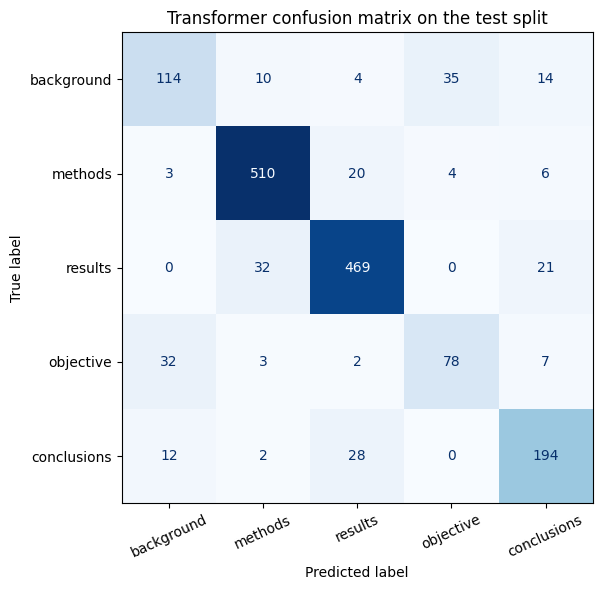

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
cm = confusion_matrix(test_output.label_ids, np.argmax(test_output.predictions, axis=-1), labels=list(range(len(LABEL_LIST))))
ConfusionMatrixDisplay(cm, display_labels=LABEL_LIST).plot(ax=ax, cmap='Blues', xticks_rotation=25, colorbar=False)
ax.set_title('Transformer confusion matrix on the test split')
plt.tight_layout()
plt.show()

## Inspect model's mistakes

From the confusion matrix above, you can easily view where the model confuses one label for the other. For a more indepth analysis, print some of the predictions to inspect the context of the sentences where this happens. Do you see any patterns?

These will become useful in Session 2, when we will dig deeper into evaluation and visualisation.

### Extra Exercise
Try to inspect the first few misclassified examples for each model(Notebook 1 DNN and This Notebook)
- Are both models making the same mistakes?
- Are the mistakes concentrated in one label?
- Do the models confuse similar sentence roles?
- Which examples seem genuinely ambiguous?

In [ ]:
# Show the first few misclassified examples
misclassified = test_df.loc[~test_df['correct']].copy()

print(f'Misclassified examples in the test split: {len(misclassified):,}')

if len(misclassified) > 0:
    display(misclassified[['text', 'true_label', 'pred_label', 'confidence']].head(10))

    print('\nA few misclassified examples by true label:')
    for label in LABEL_LIST:
        subset = misclassified.loc[misclassified['true_label'] == label].head(3)
        if len(subset) == 0:
            continue
        print(f'\n--- {label} ---')
        display(subset[['text', 'true_label', 'pred_label', 'confidence']])
else:
    print('No misclassifications found in the displayed sample.')

Misclassified examples in the test split: 235


,text,true_label,pred_label,confidence
4,Endoscopic radial artery harvest only requires...,background,conclusions,0.726782
6,HRQoL measures should assess - among other dom...,background,conclusions,0.976530
7,Four patients were excluded from the study bec...,methods,results,0.923772
11,Fenoverine acts as a synchronizer of smooth mu...,objective,background,0.756791
21,Stroke risk profiles of patients detected via ...,conclusions,results,0.987866
32,"Thus , additional analyses were conducted to e...",background,results,0.893349
35,Daytime sleepiness was significantly predicted...,conclusions,results,0.959767
40,Hydroxylapatite vehicles HSPPCs and acts as an...,objective,conclusions,0.979228
41,"Over a month period in , we recruited patients .",methods,results,0.557292
42,The purpose of these studies was to investigat...,background,objective,0.539037



A few misclassified examples by true label:

--- background ---


,text,true_label,pred_label,confidence
4,Endoscopic radial artery harvest only requires...,background,conclusions,0.726782
6,HRQoL measures should assess - among other dom...,background,conclusions,0.976530
32,"Thus , additional analyses were conducted to e...",background,results,0.893349



--- methods ---


...

,text,true_label,pred_label,confidence
82,"The unknown efficacy of products , their conne...",results,conclusions,0.975213
104,"Overall , all doses of SMT were well tolerated...",results,conclusions,0.947968
105,kg- group .,results,methods,0.789108



--- objective ---


,text,true_label,pred_label,confidence
11,Fenoverine acts as a synchronizer of smooth mu...,objective,background,0.756791
40,Hydroxylapatite vehicles HSPPCs and acts as an...,objective,conclusions,0.979228
70,Patients with cirrhosis have reduced exercise ...,objective,background,0.745439



--- conclusions ---


,text,true_label,pred_label,confidence
21,Stroke risk profiles of patients detected via ...,conclusions,results,0.987866
35,Daytime sleepiness was significantly predicted...,conclusions,results,0.959767
94,A learning curve was evident in the process me...,conclusions,results,0.976630


## Reflection questions

Use these questions to close Session 1:

1. Which model performed better on this dataset, and why do you think that happened?
2. Which labels are hardest to separate?
3. Where do you see signs of class imbalance or confusion between similar sentence roles?
4. Which outputs would you like to visualise in more detail in Session 2?
5. What would you change first if you wanted to improve performance?

### What to bring to Session 2

Please keep the saved prediction tables and metrics summary. We will use them to build confusion matrices, learning-curve style diagnostics, and W&B experiment tracking examples.